# Online CAPTCHA inference with a MAP-centered proposal

This notebook fits `AutoMAPProposal` to an image from `data/examples`,
draws exact-discrete proposal particles, and corrects them against the
original generative model with self-normalized importance weights.

$$
\widetilde z^*=\operatorname*{argmax}_{\widetilde z}
\log\gamma_{\theta,\eta}(\widetilde z;x),\qquad
\widetilde w_s=
\frac{\gamma_\theta(z^{(s)};x)/q_\phi(z^{(s)}\mid x)}
{\sum_r\gamma_\theta(z^{(r)};x)/q_\phi(z^{(r)}\mid x)}.
$$

The reconstruction is $\sum_s\widetilde w_s\mu_\theta(z^{(s)})$.
The final cells report optimizer convergence, ESS, and weight collapse.


In [1]:
from pathlib import Path

import hydra
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import rootutils
from PIL import Image

PROJECT_ROOT = rootutils.setup_root(
    Path.cwd(), indicator=".project-root", pythonpath=True
)

from src.inference.map_proposal_online import MAPProposalCaptchaInference


In [2]:
EXAMPLE_INDEX = 0
MAXITER = 20
NUM_CANDIDATES = 6
NUM_DISPERSION_PARTICLES = 8
NUM_IMPORTANCE_SAMPLES = 64
SEED = 0


def load_image(path, shape=(80, 80)):
    height, width = shape
    image = Image.open(path).convert("RGB").resize((width, height))
    array = np.asarray(image, dtype=np.float32) / 255.0
    return jnp.asarray(array)[None]


def plot_candidate_sites(axis, image, sites, strengths=None):
    axis.imshow(np.asarray(image))
    strengths = (
        np.ones(len(sites)) if strengths is None else np.asarray(strengths)
    )
    sizes = 30.0 + 90.0 * strengths / max(float(strengths.max()), 1e-6)
    axis.scatter(
        np.asarray(sites[:, 1]),
        np.asarray(sites[:, 0]),
        facecolors="none",
        edgecolors="tab:red",
        s=sizes,
    )
    axis.set_axis_off()


## Inspect the available observations

Change `EXAMPLE_INDEX` above to fit a different image. The inference cells
operate on whichever path is selected from this gallery.


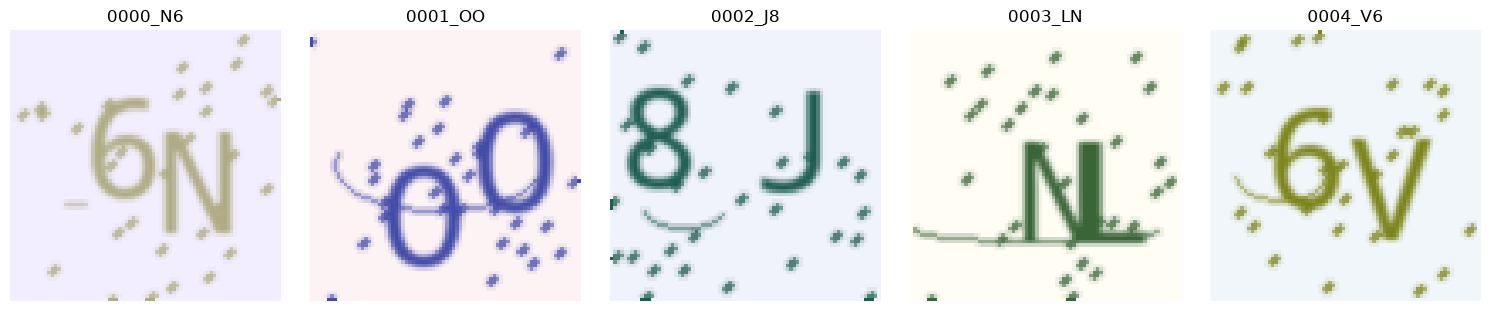

In [3]:
example_paths = sorted((PROJECT_ROOT / "data/examples").glob("*.png"))
if not example_paths:
    raise FileNotFoundError(PROJECT_ROOT / "data/examples")

figure, axes = plt.subplots(
    1, len(example_paths), figsize=(3 * len(example_paths), 3),
    constrained_layout=True, squeeze=False,
)
for axis, path in zip(axes[0], example_paths):
    axis.imshow(np.asarray(load_image(path)[0]))
    axis.set_title(path.stem)
    axis.set_axis_off()
selected_path = example_paths[EXAMPLE_INDEX]


## Fit and freeze the proposal

The first optimization locates a mode of the DSGD-relaxed target. The
second fits proposal dispersions with fixed Monte Carlo randomness. The
proposal is then frozen while the exact importance particles are drawn.
The full canonical texture and affine-free image warp remain latent. The
initializer places count mass on the best class at each candidate location,
uses a dark image percentile for color, and sets both fields to zero. Every
objective evaluation still retains the original Poisson prior.


In [4]:
config_directory = str(PROJECT_ROOT / "configs")
with hydra.initialize_config_dir(
    config_dir=config_directory, version_base="1.3"
):
    model_config = hydra.compose(config_name="model/poisson_convsc")
model_config.model.placements.shape_dict.path = str(
    PROJECT_ROOT / "data/captcha_sandbox/dictionary"
)
model = hydra.utils.instantiate(model_config.model)
images = load_image(
    selected_path,
    (model.keywords["placements"].height,
     model.keywords["placements"].width),
)
inference = MAPProposalCaptchaInference(
    model,
    dsgd_kwargs={"max_count": 16, "width": 32},
    num_candidates=NUM_CANDIDATES,
    num_dispersion_particles=NUM_DISPERSION_PARTICLES,
    num_importance_samples=NUM_IMPORTANCE_SAMPLES,
    optimizer_options={"maxiter": MAXITER},
)
result = inference(jax.random.key(SEED), images)


Text(0.5, 1.0, 'Candidates sized by weighted count')

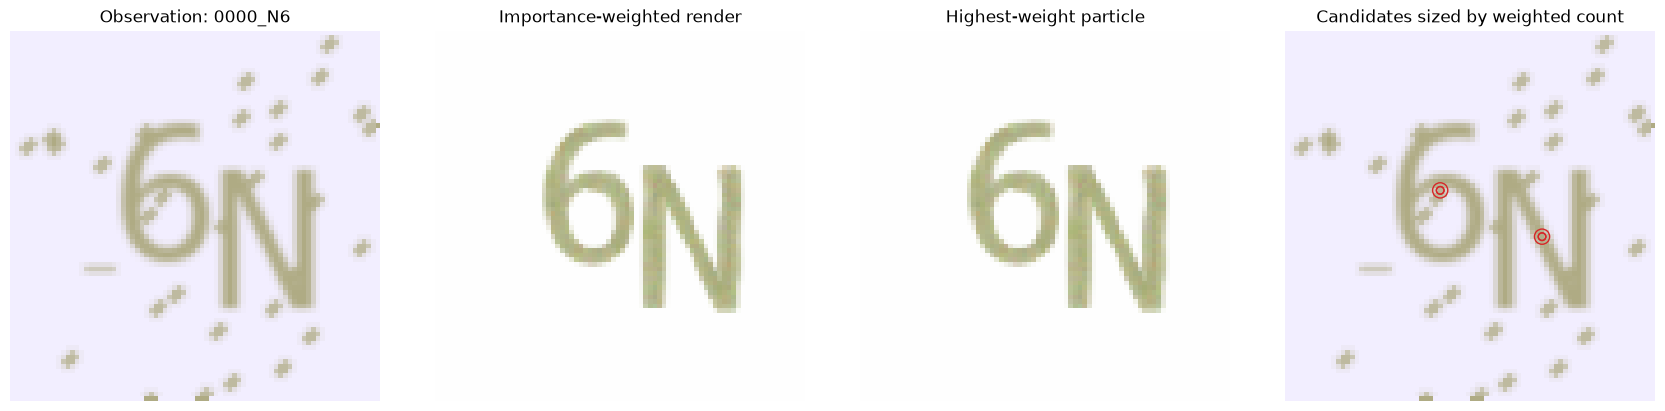

In [5]:
count_particles = np.asarray(result.samples["candidate_counts"])[:, 0]
normalized_weights = np.asarray(result.normalized_weights)
top_particle = int(np.argmax(normalized_weights))
weighted_counts = np.sum(
    normalized_weights[:, None] * count_particles, axis=0
)
weighted_reconstruction = np.asarray(result.weighted_reconstruction)[0]

figure, axes = plt.subplots(1, 4, figsize=(17, 4),
                            constrained_layout=True)
axes[0].imshow(np.asarray(images[0]))
axes[0].set_title(f"Observation: {selected_path.stem}")
axes[0].set_axis_off()
axes[1].imshow(np.clip(weighted_reconstruction, 0.0, 1.0))
axes[1].set_title("Importance-weighted render")
axes[1].set_axis_off()
axes[2].imshow(np.clip(
    np.asarray(result.reconstructions[top_particle, 0]), 0.0, 1.0
))
axes[2].set_title("Highest-weight particle")
axes[2].set_axis_off()
plot_candidate_sites(
    axes[3], images[0], result.candidate_sites, weighted_counts
)
axes[3].set_title("Candidates sized by weighted count")


MAP converged: False
Dispersion fit converged: False
ESS: 1.00 / 64
Largest weight: 1.0000
Candidate sites:
[[44 55 23]
 [44 55 17]
 [44 55 30]
 [34 33  6]
 [34 33  5]
 [34 33 16]]
Importance-weighted counts:
[1. 0. 0. 1. 0. 0.]


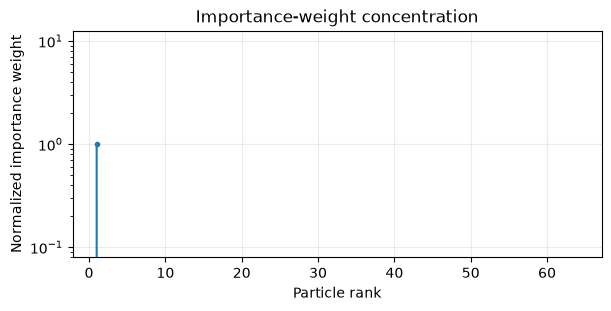

In [6]:
ordered_weights = np.sort(normalized_weights)[::-1]
figure, axis = plt.subplots(figsize=(6, 3), constrained_layout=True)
axis.semilogy(np.arange(1, len(ordered_weights) + 1),
              ordered_weights, marker=".")
axis.set_xlabel("Particle rank")
axis.set_ylabel("Normalized importance weight")
axis.set_title("Importance-weight concentration")
axis.grid(alpha=0.25)
print(f"MAP converged: {bool(result.map_converged)}")
print(f"Dispersion fit converged: {bool(result.dispersion_converged)}")
print(f"ESS: {float(result.effective_sample_size):.2f} / "
      f"{NUM_IMPORTANCE_SAMPLES}")
print(f"Largest weight: {float(ordered_weights[0]):.4f}")
print(f"Candidate sites:\n{np.asarray(result.candidate_sites)}")
print(f"Importance-weighted counts:\n{weighted_counts.round(3)}")
assert np.isfinite(weighted_reconstruction).all()
assert np.isclose(normalized_weights.sum(), 1.0)


## Interpretation

An ESS near one means that a single particle dominates: the computation
worked, but $q_\phi$ did not cover the relevant posterior well enough for
the chosen particle count. Non-convergence has the same status. If BFGS
emits an invalid proposal log-parameter, the implementation substitutes the
guide's initial full-support value. This changes $q_\phi$, not
$\gamma_\theta$, so importance correction is still valid. Candidate
selection remains an additional approximation because omitted glyph sites
cannot receive posterior mass.
